In [1]:
import pennylane as qml
import numpy as np

In [3]:
data_qubit = 3
ancilla_qubit = 2
n_qubits = data_qubit + ancilla_qubit

In [4]:
dev = qml.device("default.qubit", wires=n_qubits)

In [2]:
def encode(single_qubit_statevecter):
    """Encode a single qubit statevector into a quantum circuit.

    Args:
        single_qubit_statevecter (array[complex]): A 2-dimensional array representing the statevector of a single qubit.

    Returns:
        qml.QNode: A quantum circuit that prepares the given statevector.
    """
    qml.StatePrep(single_qubit_statevecter, wires=0)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[0, 2])

In [5]:
def error_detection():
    """Construct a quantum circuit for error detection in a stabilizer code.

    This function creates a quantum circuit that performs error detection using ancilla qubits. It applies CNOT gates to entangle the data qubits with the ancilla qubits, allowing for the detection of errors in the data qubits.

    Returns:
        qml.QNode: A quantum circuit that performs error detection.
    """
    qml.CNOT(wires=[0, 3])
    qml.CNOT(wires=[1, 3])
    qml.CNOT(wires=[1, 4])
    qml.CNOT(wires=[2, 4])

In [6]:
@qml.set_shots(1)
@qml.qnode(dev)
def syndrome_measurement(single_qubit_statevecter, error_wire):
    """Perform syndrome measurement for error detection in a stabilizer code.

    This function encodes a single qubit statevector, applies error detection, and measures the ancilla qubits to obtain the syndrome information.

    Args:
        single_qubit_statevecter (array[complex]): A 2-dimensional array representing the statevector of a single qubit.

    Returns:
        list[int]: The measurement results of the ancilla qubits, representing the syndrome information.
    """
    encode(single_qubit_statevecter)
    qml.Barrier()

    qml.PauliX(wires=error_wire) # Unwanted Pauli X error
    qml.Barrier()

    error_detection()
    return qml.sample(wires=[3, 4])

In [7]:
single_qubit_input = np.array([1, 1j]) / np.sqrt(2)  # Example single qubit statevector
error_wire = 1  # Example error on the second data qubit
syndrome = syndrome_measurement(single_qubit_input, error_wire)
print("Syndrome measurement results:", syndrome)

Syndrome measurement results: [[1 1]]


In [14]:
@qml.qnode(qml.device("default.qubit", wires=data_qubit))
def non_error_state(single_qubit_statevecter):
    """Construct a quantum circuit to prepare a non-error state in a stabilizer code.

    This function encodes a single qubit statevector and applies error detection without introducing any errors. It is used to verify that the syndrome measurement correctly identifies the absence of errors.

    Args:
        single_qubit_statevecter (array[complex]): A 2-dimensional array representing the statevector of a single qubit.

    Returns:
        list[int]: The measurement results of the ancilla qubits, representing the syndrome information for a non-error state.
    """
    encode(single_qubit_statevecter)
    return qml.density_matrix(wires=range(data_qubit))

In [10]:
@qml.qnode(dev)
def error_correction(single_qubit_statevecter, error_wire):
    """Perform error correction based on syndrome measurement results.

    This function encodes a single qubit statevector, applies error detection, and then applies corrective operations based on the syndrome measurement results.

    Args:
        single_qubit_statevecter (array[complex]): A 2-dimensional array representing the statevector of a single qubit.

    Returns:
        list[int]: The measurement results of the data qubits after error correction.
    """
    encode(single_qubit_statevecter)
    qml.Barrier()

    qml.PauliX(wires=error_wire) # Unwanted Pauli X error
    qml.Barrier()

    error_detection()
    
    # Mid circuit measurement for error correction
    m3 = qml.measure(wires=3)
    m4 = qml.measure(wires=4)

    # Operations conditional on the measurement results
    qml.cond(m3  & ~m4, qml.PauliX)(wires=0)  # Correct error on qubit 0 if syndrome indicates an error
    qml.cond(m3  &  m4, qml.PauliX)(wires=1)  # Correct error on qubit 1 if syndrome indicates an error
    qml.cond(~m3 &  m4, qml.PauliX)(wires=2)  # Correct error on qubit 2 if syndrome indicates an error

    return qml.density_matrix(
        wires=[0, 1, 2]
        )

(<Figure size 1800x700 with 1 Axes>, <Axes: >)

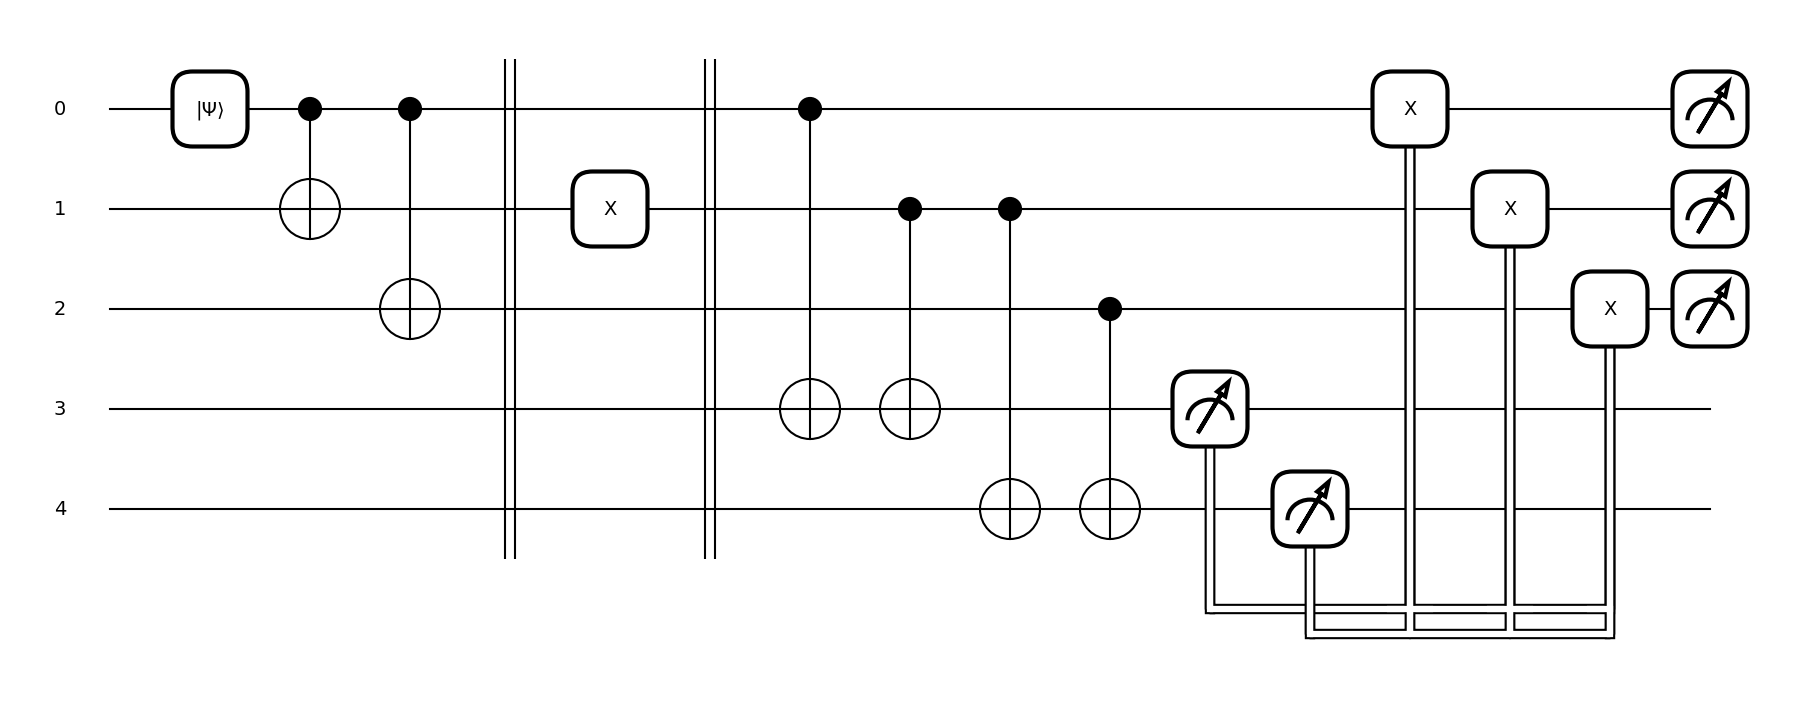

In [12]:
qml.draw_mpl(error_correction)(single_qubit_input, error_wire)

In [18]:
print(error_correction(single_qubit_input, error_wire=0))
print(non_error_state(single_qubit_input))
print("Same?", np.allclose(error_correction(single_qubit_input, error_wire=0), non_error_state(single_qubit_input)))

[[0.5+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. -0.5j]
 [0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j ]
 [0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j ]
 [0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j ]
 [0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j ]
 [0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j ]
 [0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j ]
 [0. +0.5j 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0.5+0.j ]]
[[0.5+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. -0.5j]
 [0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j ]
 [0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j ]
 [0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j ]
 [0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j ]
 [0. +0.j  0. +0.j  0. +